
# Домашнее задание 7: Metric learning + GradCam for embeddings

Обучим сеть, решающую задачу metric learning на датасете СARS196, https://paperswithcode.com/sota/metric-learning-on-cars196

Данные можно найти по ссылкам:
* meta : https://drive.google.com/file/d/1PD-lbbcKSelDeAYKafe3boc5mqqEe7X7/view?usp=sharing
* data : https://drive.google.com/file/d/1l9EnYMC-xGX706SY1kN8RceMmFViASfx/view?usp=sharing

А также рассмотрим библиотеку GradCam для интерпретации работы моделей компьютерного зрения:
repo - https://github.com/jacobgil/pytorch-grad-cam

paper - https://arxiv.org/abs/1610.02391

In [ ]:
!pip install pytorch_metric_learning
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 77.9 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import cv2
import os
import matplotlib.pyplot as plt
import random
import pandas as pd
import tqdm
import numpy as np
device = 'cuda'

Датасет, который можно скачать по ссылка выше, содержит аннотации несовместимые с изображениями. CARS196 в конечном счете был взят с https://www.kaggle.com/datasets/jutrera/stanford-car-dataset-by-classes-folder

Этот датасет я загружаю с google диска

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/CARS196.zip'
extract_to = '/content/CARS196'
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

In [ ]:
import pandas as pd
import os

data_root = '/content/CARS196/CARS196'

names_df = pd.read_csv(os.path.join(data_root, 'names.csv'), header=None)
id_to_car = {idx: name.strip() for idx, name in enumerate(names_df[0])}

train_ann = pd.read_csv(os.path.join(data_root, 'anno_train.csv'), header=None)

# class_id — 1-based преобразуем в 0-based
filenames = train_ann[0].astype(str)
class_ids = train_ann[5].astype(int) - 1

fname_to_class = dict(zip(filenames, class_ids))

In [ ]:
ADD_PATH = data_root + '/car_data/car_data/cars_train'

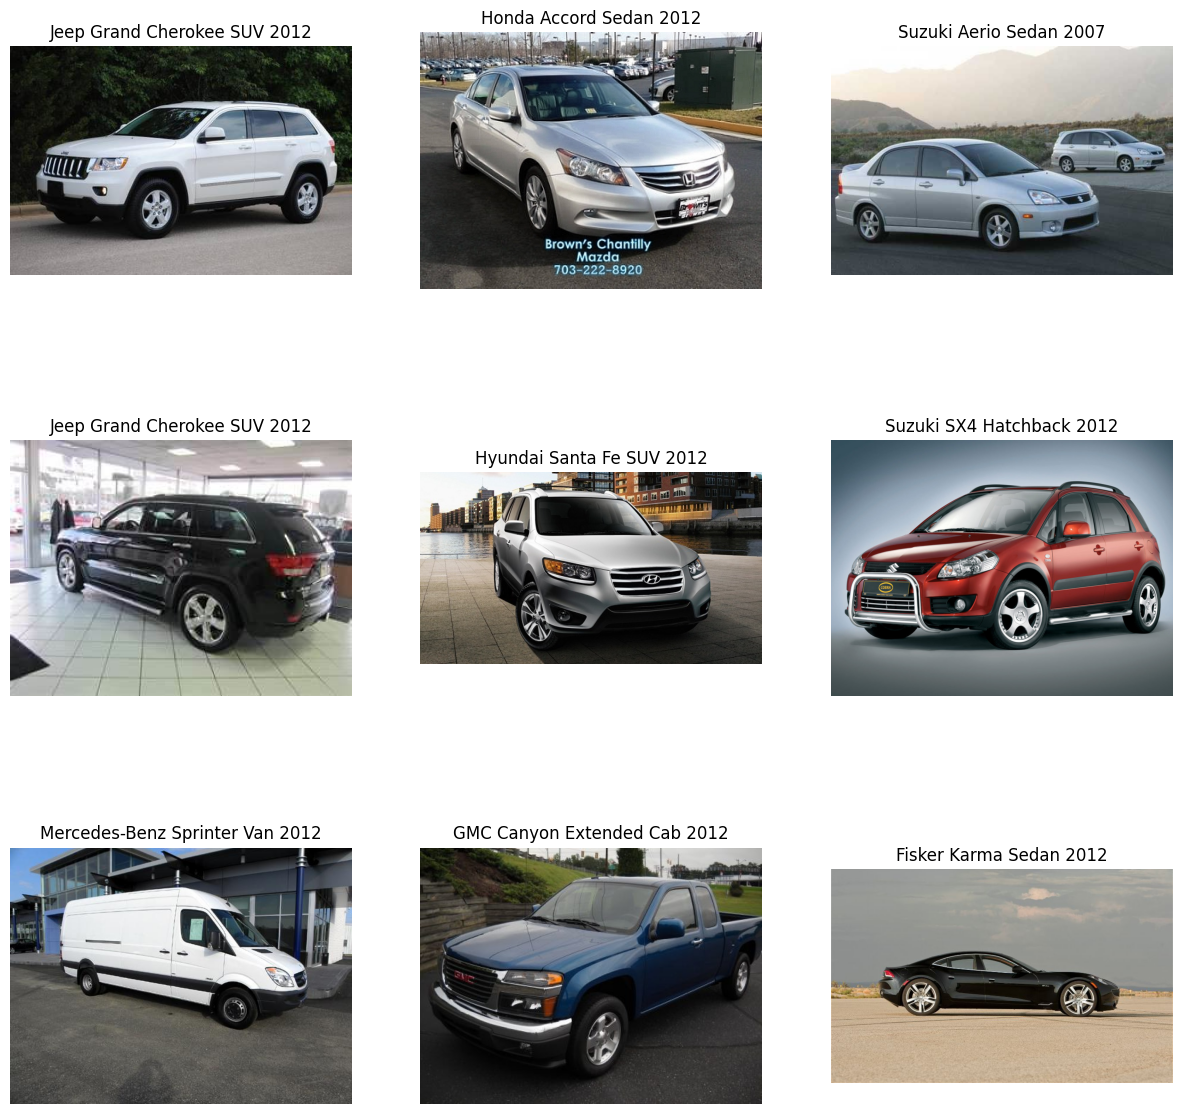

In [ ]:
num_imgs = 9
cols = 3
rows = num_imgs // cols
fig, ax = plt.subplots(rows, cols, figsize = (15, 15))
for idx, im_idx in enumerate(random.sample([i for i in range(len(fname_to_class))], num_imgs)):
    filename, cl_id = list(fname_to_class.items())[im_idx]
    temp_image = cv2.imread(os.path.join(ADD_PATH, filename))
    temp_image = cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB)
    ax[idx//cols][idx%cols].imshow(temp_image)
    ax[idx//cols][idx%cols].set_title(f'{id_to_car[cl_id]}')
    ax[idx//cols][idx%cols].axis('off')

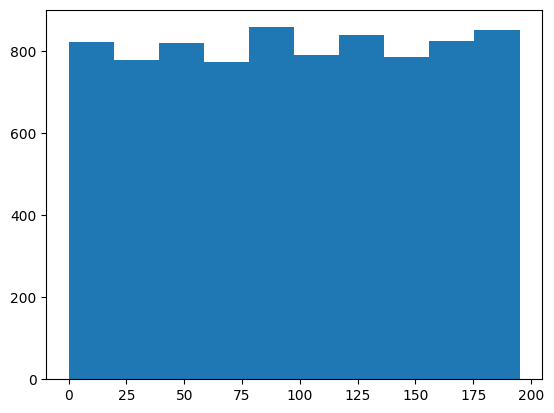

In [ ]:
plt.hist(fname_to_class.values())
plt.show()

Определим аугментации для тренировочный выборки и необходимые трансформации для валидационной

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToPILImage(),
            torchvision.transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.8, 1.2)),
            torchvision.transforms.RandomHorizontalFlip(p=0.5),
            torchvision.transforms.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
            ),
            torchvision.transforms.RandomApply([
                torchvision.transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))
            ], p=0.3),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            ])

val_transforms =  torchvision.transforms.Compose([
            torchvision.transforms.ToPILImage(),
            torchvision.transforms.Resize(
                size=(224, 224)
            ),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            ])

In [ ]:
class CropClassifDataset(torch.utils.data.Dataset):
    def __init__(self, cars_items, transforms):
        self.cars = cars_items
        self.transforms = transforms

    def __len__(self):
        return len(self.cars)

    def __getitem__(self, idx):
        filename, cl_id = self.cars[idx]
        image = cv2.imread(os.path.join(ADD_PATH, filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transforms:
            image = self.transforms(image)
        sample = {'image': image, 'label': cl_id}
        return sample

In [ ]:
items = list(fname_to_class.items())
random.shuffle(items)
train_items = items[:int(len(items) * 0.8)]
val_items = items[int(len(items) * 0.8):]

train_dataset = CropClassifDataset(train_items, train_transforms)
val_dataset = CropClassifDataset(val_items, val_transforms)

Выведем примеры аугментаций, применяемых на тренировочной выборке.

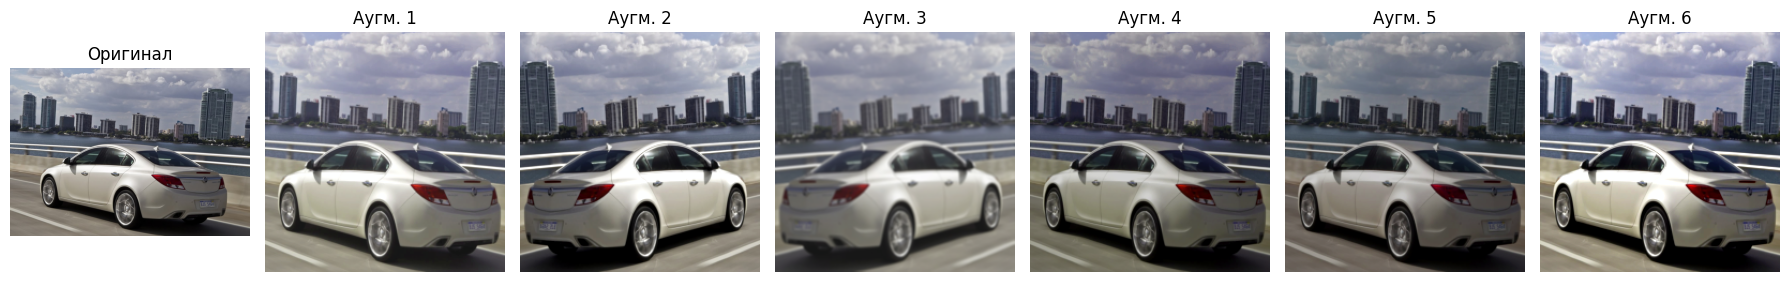

In [ ]:
filename, cl_id = random.choice(train_items)
image_path = os.path.join(ADD_PATH, filename)

orig_img = cv2.imread(image_path)
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

num_augs = 6
fig, axes = plt.subplots(1, num_augs + 1, figsize=(18, 5))

axes[0].imshow(orig_img)
axes[0].set_title("Оригинал")
axes[0].axis("off")

for i in range(num_augs):
    aug_img = train_transforms(orig_img)
    aug_img_np = np.transpose(aug_img.numpy(), (1, 2, 0))
    aug_img_np = np.clip((aug_img_np * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406])), 0, 1)
    axes[i+1].imshow(aug_img_np)
    axes[i+1].set_title(f"Аугм. {i+1}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

Контрастные методы требуют опреленного разнообразия элементов в батчах. В частости, triplet loss требует, чтобы в обрабатываемом батче было, как минмимум два представителя одного класса (anchor и pos), а также, чтобы все элементы батча не принадлежали одному классу (должен быть neg). Даже при соблюдении этих условий количество подходящих троек в случайных батчах может сильно отличаться от батча к батчу. Чтобы сделать обучение стабильным, нужно обеспечить батчи достаточно разнообразными семлпами, в идеале, сделав количество подходящих троек потостоянным. Это можно сделать, формируя батч по следующему принципу: случайно выбирается *P* классов из всех возможных классов, далее из всей тренировочной выборки случайно выбирается *K* представителей каждого из этих классов. Таким образом, у каждого элемента в батче в роли anchor будет как минимум еще один элемент (при *K* > 1) того же класса (pos) и как минимум один элемент (*P* > 1) другого класса (neg)

In [ ]:
from torch.utils.data import Sampler
from collections import defaultdict
import random

class PKSampler(Sampler):
    def __init__(self, dataset, P, K, batches_per_epoch=None):
        """
        dataset: объект Dataset, у которого есть поле .cars (список (fname, label))
        P: сколько классов на батч
        K: сколько образцов на класс
        batches_per_epoch: сколько батчей выдавать за эпоху
        """
        self.P = P
        self.K = K
        # не вызываем dataset[i], чтобы не загружать изображения!
        self.labels = [lbl for _, lbl in dataset.cars]
        self.label_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.label_to_indices[label].append(idx)

        self.classes = list(self.label_to_indices.keys())
        self.batches_per_epoch = batches_per_epoch or max(1, len(self.labels) // (P * K))

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            # выбираем P случайных классов
            selected_classes = random.sample(self.classes, self.P)
            indices = []
            for cls in selected_classes:
                candidates = self.label_to_indices[cls]
                if len(candidates) >= self.K:
                    chosen = random.sample(candidates, self.K)
                else:
                    # если меньше K — выбираем с повторением
                    chosen = random.choices(candidates, k=self.K)
                indices.extend(chosen)
            yield indices

    def __len__(self):
        return self.batches_per_epoch


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_sampler=PKSampler(train_dataset, P=8, K=4, batches_per_epoch=500),
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=PKSampler(val_dataset, P=8, K=4, batches_per_epoch=125),
    num_workers=2,
    pin_memory=True
)

In [ ]:
batch = next(iter(train_loader))
len(batch['label']), batch['label'][:10]

(32, tensor([149, 149, 149, 149, 152, 152, 152, 152, 128, 128]))

В качестве стратегии формирования троек для triplet loss возьмем **HARD BATCH**: для данного anchor выбираем самого удаленного от него представителя того же класса (pos) и самого ближайшего представителя какого-либо другого класса (neg).

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TripletLoss(nn.Module):
    def __init__(self, alpha=0.2):
        super(TripletLoss, self).__init__()
        self.alpha = alpha

    def forward(self, x, labels):
        x = F.normalize(x, p=2, dim=1) # Лучше использовать нормированные векторы, чтобы alpha не зависел от размерности
        B = x.size(0)

        dist = torch.cdist(x, x, p=2).pow(2)

        labels_eq = labels.unsqueeze(0) == labels.unsqueeze(1)
        mask_pos = labels_eq & (~torch.eye(B, dtype=torch.bool, device=x.device))
        mask_neg = ~labels_eq

        hardest_pos = torch.where(mask_pos, dist, torch.zeros_like(dist)).max(dim=1)[0]

        dist_neg = torch.where(mask_neg, dist, torch.full_like(dist, float('inf')))
        hardest_neg = dist_neg.min(dim=1)[0]

        loss = F.relu(hardest_pos - hardest_neg + self.alpha)
        return loss.mean()

In [ ]:
!pip install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 56.2 MB/s eta 0:00:00


В качестве backbone будем использовать efficientnet_b0

In [ ]:
from pytorch_metric_learning import losses
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor
from torchvision.models import efficientnet_b0

class CarEmbedder(pl.LightningModule):
    def __init__(self, class_dict, learning_rate, emb_size):
        super().__init__()
        self.learning_rate = learning_rate

        self.model = efficientnet_b0(pretrained=True)

        self.model.classifier = torch.nn.Sequential(
                            torch.nn.Linear(in_features=1280, out_features=emb_size))

        self.triplet_loss = TripletLoss()

        self.save_hyperparameters()

    def training_step(self, batch, batch_idx):
        images = batch['image']
        labels = batch['label'].to(torch.long)
        latents = self.model(images)
        loss = self.triplet_loss(latents, labels)

        self.log("train_loss", loss, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images = batch['image']
        labels = batch['label'].to(torch.long)
        latents = self.model(images)
        loss = self.triplet_loss(latents, labels)

        self.log("validation_loss", loss, sync_dist=True)

    def forward(self, images):
        if len(images.shape) == 4:
            preds = self.model(images)
        else:
            preds = self.model(images.unsqueeze(0))
        return preds

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return [optimizer]

In [ ]:
# model
pl_model = CarEmbedder(id_to_car, 3e-4, 512)
checkpoint_callback = ModelCheckpoint(monitor='validation_loss',mode='min',  save_top_k=3)
early_stopping = EarlyStopping(monitor="validation_loss", mode="min", patience=2)
lr_monitor = LearningRateMonitor(logging_interval='step')

# train model
trainer = pl.Trainer(
    max_epochs=40,
    accelerator=device,
    devices=1,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model=pl_model, train_dataloaders=train_loader,
            val_dataloaders=val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name         | Type         | Params | Mode 
------------------------------------------------------
0 | model        | EfficientNet | 4.7 M  | train
1 | triplet_loss | TripletLoss  | 0      | train
------------------------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.654    Total estimated model params size (MB)
337       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name         | Type         | Params | Mode 
------------------------------------------------------
0 | model        | EfficientNet | 4.7 M  | train
1 | triplet_loss | TripletLoss  | 0      | train
------------------------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.654    Total estimated 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
trainer.validate(model=pl_model, dataloaders=val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      validation_loss      │    0.20034204423427582    │
└───────────────────────────┴───────────────────────────┘

[{'validation_loss': 0.20034204423427582}]

# Поиск похожих
Поиск наиболее похожих элементов (документов, товаров, пользователей...) согласно заданной метрике близости или расстояния (Жаккард, Косинус, Евклид,...)

Классические примеры: k-ближайших соседей, ранжирование (рексистемы,чат-боты, распознавание лиц, ), дедупликация документов

Расстояние – переводит пару элементов некоторого пространства в вещественное число
Должно удовлетворять условиям:
1. Расстояние неотрицательно
2. Расстояние равно нулю только тогда, когда
совпадают элементы
3. Расстояние симметрично  
Примеры: Jaccard, Euclidian, Cosine

<img src="images/vectors.png"  width="50%" height="30%">



In [ ]:
pl_model.eval()
pl_model.to(device)
np.float32

numpy.float32

In [ ]:
def get_embeds(model, loader):
    embeddings = np.empty((1,512))
    labels = np.empty((1))
    for batch in tqdm.tqdm_notebook(loader):
        imgs = batch['image']
        label = batch['label']
        with torch.no_grad():
            preds = model(imgs.to(device))
        embeddings = np.concatenate([embeddings, preds.cpu().numpy()])
        labels = np.concatenate([labels, label.numpy()])
    return embeddings[1:].astype(np.float32), labels[1:]

In [ ]:
train_emb, train_labels = get_embeds(pl_model, train_loader)
val_emb, val_labels = get_embeds(pl_model, val_loader)

/tmp/ipython-input-3342089651.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm.tqdm_notebook(loader):


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

In [ ]:
train_emb.shape

(16000, 512)

In [ ]:
import faiss                   # make faiss available
index = faiss.IndexFlatL2(512)   # build the index
print(index.is_trained)
index.add(train_emb)                  # add vectors to the index
print(index.ntotal)
print()

k = 4                          # we want to see 4 nearest neighbors
D, I = index.search(train_emb[:5], k) # sanity check
print(I)
print()
print(D)
print()
D, I = index.search(val_emb, k)     # actual search
print(I[:5])                   # neighbors of the 5 first queries
print()
print(I[-5:])
print()

True
16000

[[    0 14542  2184  9473]
 [    1 10582 14543  7543]
 [    2 11925  1303 14311]
 [    3  1259  7467 14308]
 [    4  5870 12314  8076]]

[[ 0.          0.27162075  0.5431906   1.6424731 ]
 [ 0.          2.197002    2.2557297  11.148888  ]
 [ 0.          0.43741786  1.4239731   1.7594445 ]
 [ 0.          1.6810851   2.1304898   2.9770384 ]
 [ 0.          0.22503398  0.81781036  1.5878909 ]]

[[15707  6278 10534 15344]
 [ 4904  9020 11837 14251]
 [15105 15833  4933 15869]
 [10694   401  6565  1002]
 [11988  3697 14401 11062]]

[[ 2424  8721 13282  8312]
 [14729  5422  8934 14951]
 [ 2650   206    11  5574]
 [15293 12527  7377 12210]
 [14773  3302 15911  6110]]



Проверим, какие метки будут у ближайших соседей элементов из валидационной выборки

In [ ]:
id_to_car[val_labels[3]]

'Lamborghini Reventon Coupe 2008'

In [ ]:
id_to_car[train_labels[I[2][0]]], id_to_car[train_labels[I[2][1]]], id_to_car[train_labels[I[2][2]]], id_to_car[train_labels[I[2][3]]]

('Lamborghini Reventon Coupe 2008',
 'Lamborghini Reventon Coupe 2008',
 'Lamborghini Reventon Coupe 2008',
 'Lamborghini Reventon Coupe 2008')

Очень хорошо. Все четыре ближайших соседа являются представителями того же класса.

In [ ]:
id_to_car[val_labels[-1]]

'Audi S5 Coupe 2012'

In [ ]:
id_to_car[train_labels[I[-1][0]]], id_to_car[train_labels[I[-1][1]]], id_to_car[train_labels[I[-1][2]]], id_to_car[train_labels[I[-1][3]]]

('Audi TTS Coupe 2012',
 'Audi S5 Coupe 2012',
 'Audi TTS Coupe 2012',
 'Audi S6 Sedan 2011')

Вместе с правильной меткой в топ попали и другие. Видно, что модели машин, попавшие в топ похожи, особенно модели Audi S5 и S6

Реализуем метрики Precision@K, Recall@K, mAP@K.

In [ ]:
def precision_at_k(train_labels, val_labels, indices, k=5):
    """
    Precision@k — средняя доля правильных классов среди top-k ближайших соседей.
    """
    retrieved_labels = train_labels[indices[:, :k]]
    correct = (retrieved_labels == val_labels[:, None])
    precision = correct.sum(axis=1) / k
    return precision.mean()


def recall_at_k(train_labels, val_labels, indices, k=5):
    """
    Recall@k — доля запросов, у которых хотя бы один сосед в top-k правильный.
    """
    retrieved_labels = train_labels[indices[:, :k]]
    correct = (retrieved_labels == val_labels[:, None])
    recall = correct.any(axis=1).astype(np.float32)
    return recall.mean()

def average_precision_at_k(train_labels, val_label, indices, k=5):
    """
    AP для одного запроса
    train_labels: (N_train,)
    val_label: int
    indices: array-like, топ-k индексы ближайших соседей
    """
    retrieved_labels = train_labels[indices[:k]]
    relevant = (retrieved_labels == val_label).astype(np.float32)

    if relevant.sum() == 0:
        return 0.0

    precisions = np.cumsum(relevant) / (np.arange(1, k+1))
    ap = (precisions * relevant).sum() / relevant.sum()
    return ap


def mean_average_precision_at_k(train_labels, val_labels, indices, k=5):
    """
    mAP@k для всей валидации
    indices: (N_val, k)
    """
    aps = []
    for i in range(val_labels.shape[0]):
        ap = average_precision_at_k(train_labels, val_labels[i], indices[i], k)
        aps.append(ap)
    return np.mean(aps)

In [ ]:
D, I = index.search(val_emb, 5)

In [ ]:
prec1 = precision_at_k(train_labels, val_labels, I, k=1)
rec1 = recall_at_k(train_labels, val_labels, I, k=1)
prec5 = precision_at_k(train_labels, val_labels, I, k=5)
rec5 = recall_at_k(train_labels, val_labels, I, k=5)

map1 = mean_average_precision_at_k(train_labels, val_labels, I, k=1)
map5 = mean_average_precision_at_k(train_labels, val_labels, I, k=5)

print(f"Precision@1: {prec1:.4f}")
print(f"Recall@1:    {rec1:.4f}")
print(f"Precision@5: {prec5:.4f}")
print(f"Recall@5:    {rec5:.4f}")

print(f"mAP@1: {map1:.4f}")
print(f"mAP@5: {map5:.4f}")

Precision@1: 0.3705
Recall@1:    0.3705
Precision@5: 0.3120
Recall@5:    0.6015
mAP@1: 0.3705
mAP@5: 0.4355


В отчете не зафиксирована попытка дообучения на данных без аугментаций. mAP@1 ~ 0.65, mAP@5 ~ 0.67, Recall@5 ~ 0.8, Precision@5 ~ 0.7

# GradCam with embeds

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=52f3bb25abe82f5b13e9ee90c99cc0e818ef2fb4c1318cddd182d429f828bd05
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from PIL import Image
import requests
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

transform_to_show = torchvision.transforms.Compose([
                        torchvision.transforms.ToPILImage(),
                        torchvision.transforms.Resize(
                            size=(224, 224)
                        ),
                        torchvision.transforms.ToTensor()
                        ])

def get_image_from_path(path):
    """A function that gets a path to an image,
    and returns a numpy image and a preprocessed
    torch tensor ready to pass to the model """

    orig_im = np.array(Image.open(path).convert('RGB'))
    rgb_im = np.array(transform_to_show(orig_im).permute(1,2,0))
    transformed_im = val_transforms(orig_im).unsqueeze(0).to(device)
    orig_im = cv2.resize(orig_im, (512, 512))

    return orig_im, rgb_im, transformed_im

Проинтерпретируем дообученную на triplet loss модель (Efficient net). Будем использовать те же изображения, которые использовались на семинаре

In [ ]:
car_img, car_img_float, car_tensor = get_image_from_path("images/car.png")
cloud_img, cloud_img_float, cloud_tensor = get_image_from_path("images/cloud.png")
car_concept_features = pl_model(car_tensor)[0, :]
cloud_concept_features = pl_model(cloud_tensor)[0, :]

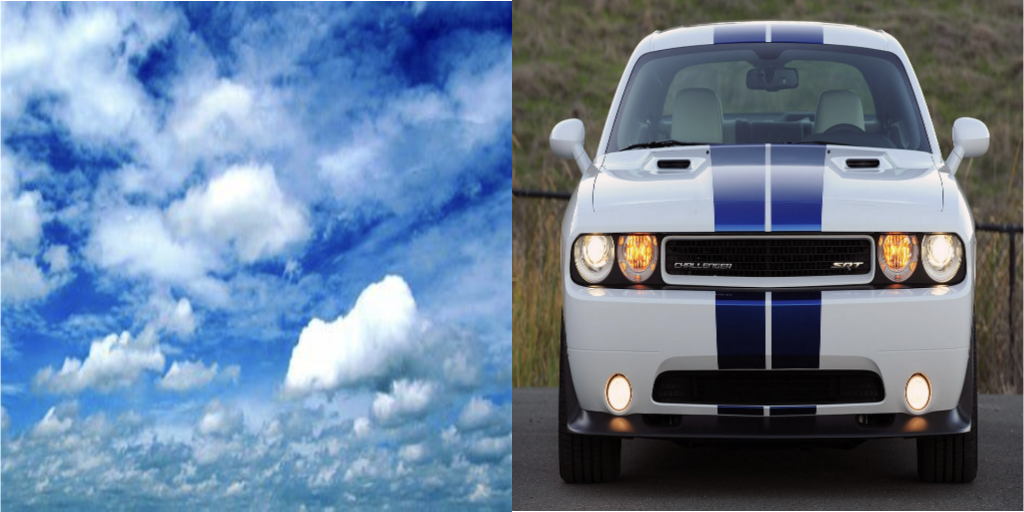

In [ ]:
Image.fromarray(np.hstack((cloud_img, car_img)))

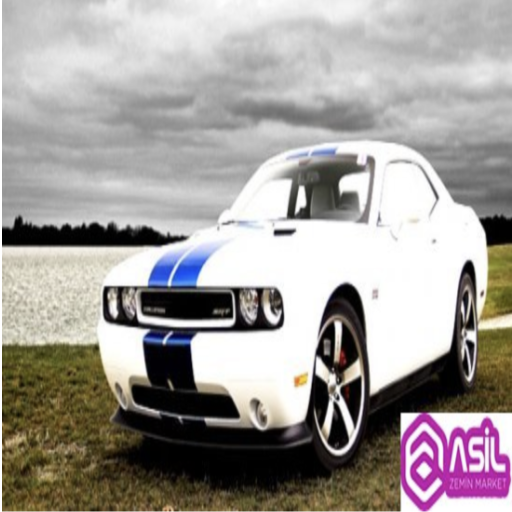

In [ ]:
image, image_float, input_tensor = get_image_from_path("images/car2.png")
Image.fromarray(image)

In [ ]:
pl_model.model.features[8]

Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)

На что "смотрела" модель, при попытке получить эмбеддинг близкий к эмбеддингу машины

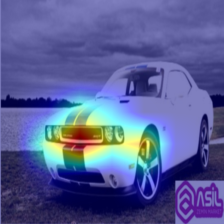

In [ ]:
class SimilarityToConceptTarget:
    def __init__(self, features):
        self.features = features

    def __call__(self, model_output):
        cos = torch.nn.CosineSimilarity(dim=0)
        return cos(model_output, self.features)

target_layers = [pl_model.model.features[8]]
car_targets = [SimilarityToConceptTarget(car_concept_features)]
cloud_targets = [SimilarityToConceptTarget(cloud_concept_features)]

# Where is the car in the image
with GradCAM(model=pl_model.model,
             target_layers=target_layers) as cam:
    car_grayscale_cam = cam(input_tensor=input_tensor,
                        targets=car_targets)[0, :]
car_cam_image = show_cam_on_image(image_float, car_grayscale_cam, use_rgb=True)
Image.fromarray(car_cam_image)

На что "смотрела" модель, при попытке получить эмбеддинг близкий к эмбеддингу небу

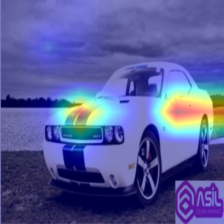

In [ ]:
# Where is the cloud in the image
with GradCAM(model=pl_model.model,
             target_layers=target_layers) as cam:
    cloud_grayscale_cam = cam(input_tensor=input_tensor,
                        targets=cloud_targets)[0, :]
cloud_cam_image = show_cam_on_image(image_float, cloud_grayscale_cam, use_rgb=True)
Image.fromarray(cloud_cam_image)

In [ ]:
class DifferenceFromConceptTarget:
    def __init__(self, features):
        self.features = features

    def __call__(self, model_output):
        cos = torch.nn.CosineSimilarity(dim=0)
        return 1 - cos(model_output, self.features)

not_car_targets = [DifferenceFromConceptTarget(car_concept_features)]
not_cloud_targets = [DifferenceFromConceptTarget(cloud_concept_features)]

На что "смотрела" модель, при попытке получить эмбеддинг далекий от эмбеддинга неба

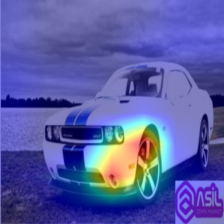

In [ ]:
# Where is the cloud not in the image?
with GradCAM(model=pl_model.model,
             target_layers=target_layers) as cam:
    not_cloud_grayscale_cam = cam(input_tensor=input_tensor,
                        targets=not_cloud_targets)[0, :]
cam_image = show_cam_on_image(image_float, not_cloud_grayscale_cam, use_rgb=True)
Image.fromarray(cam_image)

На что "смотрела" модель, при попытке получить эмбеддинг далекий от эмбеддинга машины

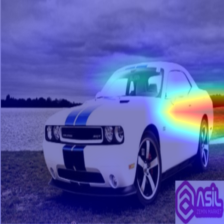

In [ ]:
# Where is the car not in the image?
with GradCAM(model=pl_model.model,
             target_layers=target_layers) as cam:
    not_car_grayscale_cam = cam(input_tensor=input_tensor,
                        targets=not_car_targets)[0, :]
cam_image = show_cam_on_image(image_float, not_car_grayscale_cam, use_rgb=True)
Image.fromarray(cam_image)

Не очень удачную интерпретацию последних трех экспериментов можно объснить. Рассмотрим второй эксперимент: ожидается, что GradCAM подсветит небо, и оно отчасти подсвечено, но сильнее всего подсвечен, капот и боковая сторона авто. Обратное распространение ошибки (ошибки несоответсвия латентного вектора машины латентному вектору неба) способствует как раз выделению неба (Grad состовляющая GradCAM). Однако модель дообучалась для оптимального кодирования АВТОМОБИЛЕЙ (все классы в тринировочной выборке были моделями автомобилей), поэтому свертки главным образом активируются на участках с авто (CAM состовляющая GradCAM). Следовательно, закономерно при прямом проходе свертки активируются сильнее всего в областях, где находится автомобиль. CAM состовлющая оказывает большее влияние на интерпретацию чем Grad состовляющая. Это объяснет то, что во всех экспериментах самые сильные активации происходили внутри контура автомобиля.

Если бы во время дообучения модель училась на данных, содержащих также класс "небо", то очень вероятно, что интерпретация была бы гораздо более логичной.

In [ ]:
car_embed = car_concept_features

In [ ]:
cloud_embed = cloud_concept_features

In [ ]:
input_embed = pl_model(input_tensor)[0, :]

In [ ]:
car_embed.shape, cloud_embed.shape, input_embed.shape

(torch.Size([512]), torch.Size([512]), torch.Size([512]))

Косинус между латентным вектором машины и неба

In [ ]:
cos = torch.nn.CosineSimilarity(dim=0)
cos(cloud_embed, input_embed)

tensor(0.2755, device='cuda:0', grad_fn=<SumBackward1>)

Косинус между латентным вектором машины и машины

In [ ]:
cos = torch.nn.CosineSimilarity(dim=0)
cos(input_embed, car_embed)

tensor(0.9200, device='cuda:0', grad_fn=<SumBackward1>)

Видно, что латентные представления разных фоторгафий машины ближе друг к другу, чем латентное предсавление машины к латентному представлению неба

### Вывод

* В работе был реализован Triplet loss со стратегией отбора троек Hard Batch и PKSampler для генерации подходящих для Triplet loss батчей.
* Была произведена аугментация данных. При сравнении с результатами обучения на данных без аугментаций (не зафиксировано в отчете) значения метрик значительно ухудшились (mAP@1 упал с ~0.65 до 0.37)
* В качестве архитектуры была взята EfficientNet b0 (с замененным классификатором).
* Были реализованы метрики Precision@K, Recall@K, mAP@K для оценки качества кодирования изображений.
* Работа модели также была проинтерпретирована с помощью метода GradCAM.